# Entrega Final

# 1. Base de datos

La base de datos se puede obtener en el siguiente enlace: 

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace: 

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 2. Método

## 2.1. Cargar los datos

In [3]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "../datasets/3_dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

In [4]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 2.2. Pre-proceso

In [5]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [6]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d

# First apply median filter
only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))


# Combine non-sensor and filtered sensor data
dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


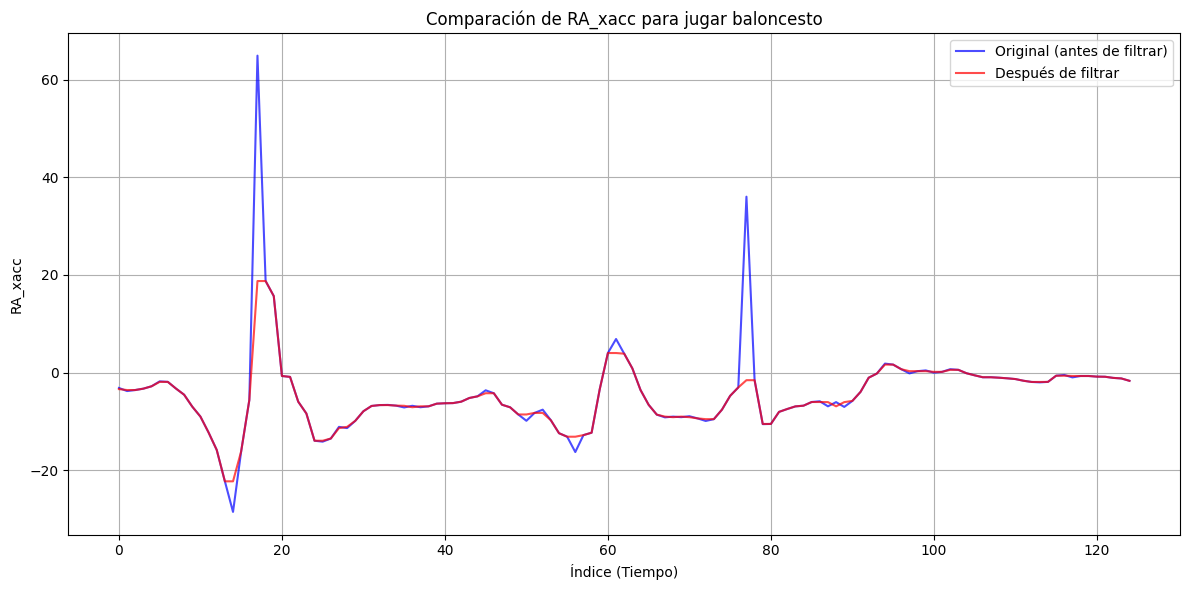

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.3. Segmentación

In [8]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [9]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

In [10]:
dsaa_no_outlier3.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

In [11]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.4. Extracción de características

In [12]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [13]:
import numpy as np
import pandas as pd

# Assume dsaa_no_outlier3 has a column 'person_id'
df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []
person_ids = []  # new list to collect person IDs

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Extract person ID (assuming column named 'person_id')
    pid = group["person_id"].iloc[0]

    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])
    person_ids.append(pid)  # add the person ID to the list

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Create DataFrame for person IDs
df_person_id = pd.DataFrame(person_ids, columns=["person_id"])

# Concatenate numeric features, labels, and person IDs
examples = pd.concat([df_numeric, df_labels, df_person_id], axis=1)

# Optionally, check the first few rows and data types
display(examples.head())
display(examples.dtypes)

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1


T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
person_id            object
Length: 242, dtype: object

In [14]:
examples

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


In [15]:
import pandas as pd

# Supongamos que tu DataFrame se llama `examples`
conteos_por_clase = examples['activity'].value_counts()

df_conteos = conteos_por_clase.rename_axis('activity').reset_index(name='count')
df_conteos

,activity,count
0,a01,800
1,a11,800
2,a18,800
3,a17,800
4,a16,800
5,a15,800
6,a14,800
7,a13,800
8,a12,800
9,a10,800


## 2.5. Entrenamiento

In [16]:
pd.set_option('display.float_format', '{:.5f}'.format)

### 2.5.1. 10-Fold Cross Validation

#### 2.5.1.1. Pipelinear Cross Validation

In [17]:
import os
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (escalador + modelo) con CV estratificada de 10 pliegues.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_10k/
    con nombre "Validación Cruzada 10P {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_encoded = y
        etiquetas = np.unique(y)

    # 1) Scorers
    precision_macro_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_macro_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_macro_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy_scorer    = 'accuracy'

    # 2) Pipeline + CV
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_encoded,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(cv.get_n_splits())
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (solo 5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        linea = "  ".join(f"{s:.5f}" for s in scores[i:i+5])
        print(f"  {linea}")
    print("\nEstadísticas de F1-macro:")
    for etiqueta, valor in stats_scores.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        linea = "  ".join(f"{t:.5f}" for t in times[i:i+5])
        print(f"  {linea}")
    print("\nEstadísticas de tiempos:")
    for etiqueta, valor in stats_times.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(pipe, X, y_encoded, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_encoded, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_10k")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada 10P {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base_name = f"Validación Cruzada 10-Folds {model.__class__.__name__}"
    fig.savefig(
        os.path.join(output_folder, f"{base_name}_1080p.png"),
        dpi=192, bbox_inches='tight'
    )
    fig.savefig(
        os.path.join(output_folder, f"{base_name}_4k.png"),
        dpi=384, bbox_inches='tight'
    )
    fig.savefig(
        os.path.join(output_folder, f"{base_name}.svg"),
        bbox_inches='tight'
    )

    return scores, times, all_scores

#### 2.5.1.2. Entrenar

1 Naive Bayes:

Puntuaciones (F1-macro):
  0.95773  0.96798  0.96765  0.95853  0.95068
  0.95977  0.96413  0.95295  0.95931  0.96069

Estadísticas de F1-macro:
Media:       0.95994
Mediana:     0.95954
Desvío:      0.00533
Mínimo:      0.95068
Máximo:      0.96798

Tiempos de entrenamiento (s):
  1.43860  1.43924  1.43804  1.42731  1.43924
  1.40605  1.42434  1.43924  1.42801  1.37827

Estadísticas de tiempos:
Media:       1.42583
Mediana:     1.43303
Desvío:      0.01875
Mínimo:      1.37827
Máximo:      1.43924


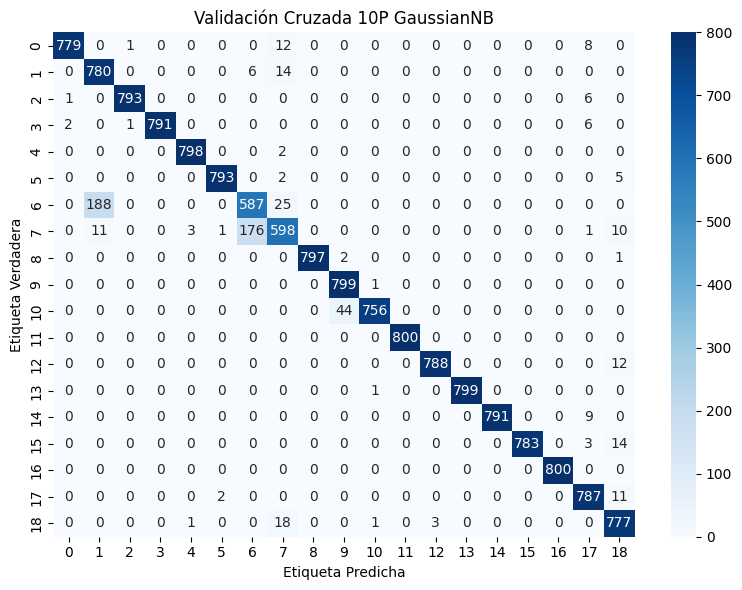

In [18]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

2 Logistic Regression

Puntuaciones (F1-macro):
  0.99399  0.99338  0.99408  0.99407  0.99278
  0.99143  0.99342  0.99214  0.99473  0.99604

Estadísticas de F1-macro:
Media:       0.99361
Mediana:     0.99370
Desvío:      0.00124
Mínimo:      0.99143
Máximo:      0.99604

Tiempos de entrenamiento (s):
  3.08611  3.22708  2.77393  3.16581  3.47966
  3.03835  3.07096  3.20411  2.97033  2.89762

Estadísticas de tiempos:
Media:       3.09140
Mediana:     3.07854
Desvío:      0.18538
Mínimo:      2.77393
Máximo:      3.47966


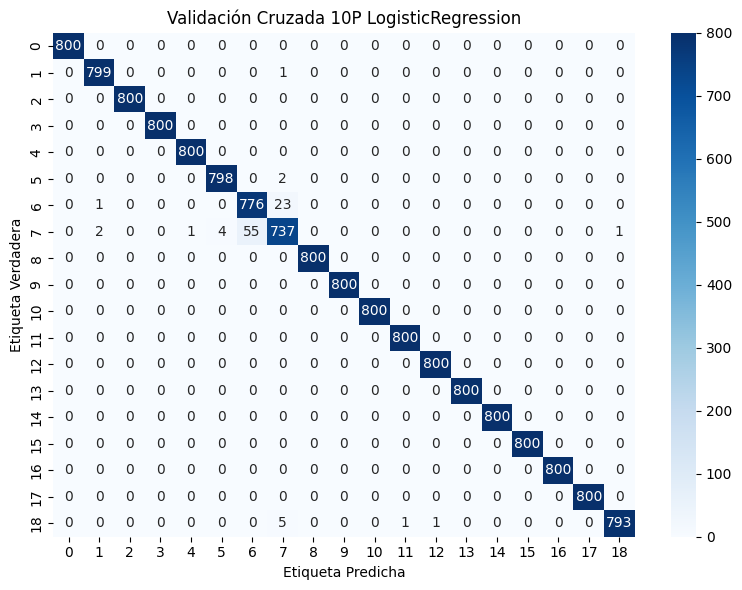

In [19]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

3 MLP

Puntuaciones (F1-macro):
  0.98830  0.99339  0.99083  0.98817  0.99340
  0.98818  0.98753  0.99015  0.99147  0.99338

Estadísticas de F1-macro:
Media:       0.99048
Mediana:     0.99049
Desvío:      0.00225
Mínimo:      0.98753
Máximo:      0.99340

Tiempos de entrenamiento (s):
  2.59496  2.67672  2.72013  2.85872  2.87222
  2.64549  2.47173  2.81640  2.76050  2.73869

Estadísticas de tiempos:
Media:       2.71556
Mediana:     2.72941
Desvío:      0.11756
Mínimo:      2.47173
Máximo:      2.87222


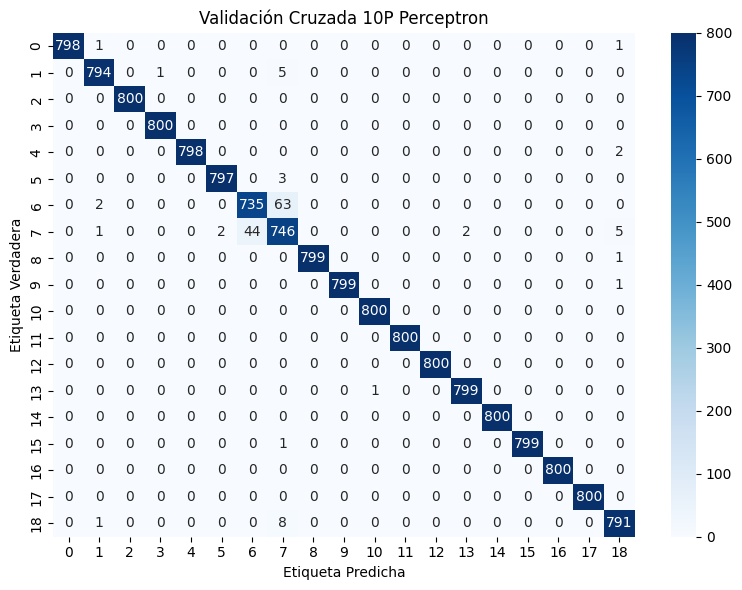

In [20]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

4 Random Forest:

Puntuaciones (F1-macro):
  0.99536  0.99737  0.99540  0.99605  0.99150
  0.99605  0.99803  0.99471  0.99541  0.99737

Estadísticas de F1-macro:
Media:       0.99573
Mediana:     0.99573
Desvío:      0.00174
Mínimo:      0.99150
Máximo:      0.99803

Tiempos de entrenamiento (s):
  32.82081  32.47418  32.59267  32.34134  32.65191
  32.26924  32.37026  32.12211  32.80889  32.52335

Estadísticas de tiempos:
Media:       32.49748
Mediana:     32.49877
Desvío:      0.21661
Mínimo:      32.12211
Máximo:      32.82081


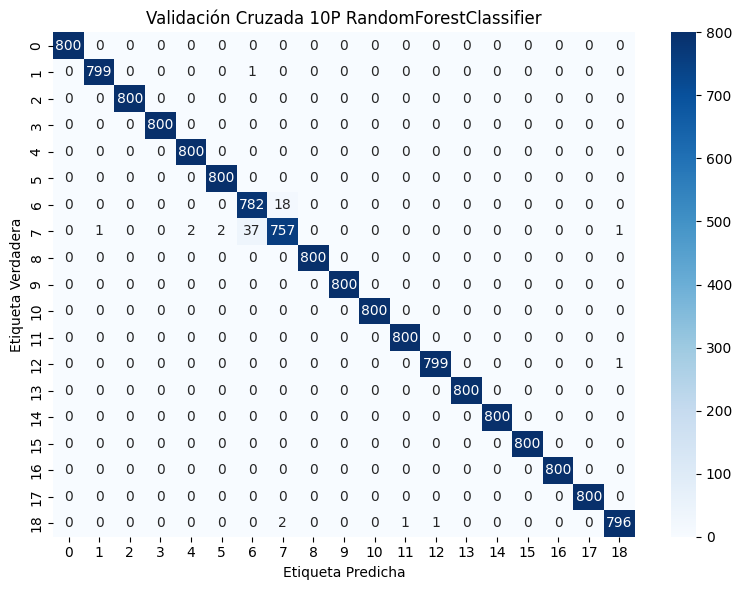

In [21]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

Puntuaciones (F1-macro):
  0.99208  0.99408  0.99019  0.99340  0.99210
  0.99342  0.99023  0.99083  0.99152  0.99213

Estadísticas de F1-macro:
Media:       0.99200
Mediana:     0.99209
Desvío:      0.00128
Mínimo:      0.99019
Máximo:      0.99408

Tiempos de entrenamiento (s):
  246.07641  245.52239  246.64680  245.63440  244.83292
  245.91772  246.10194  246.79714  246.19959  246.18609

Estadísticas de tiempos:
Media:       245.99154
Mediana:     246.08917
Desvío:      0.53613
Mínimo:      244.83292
Máximo:      246.79714


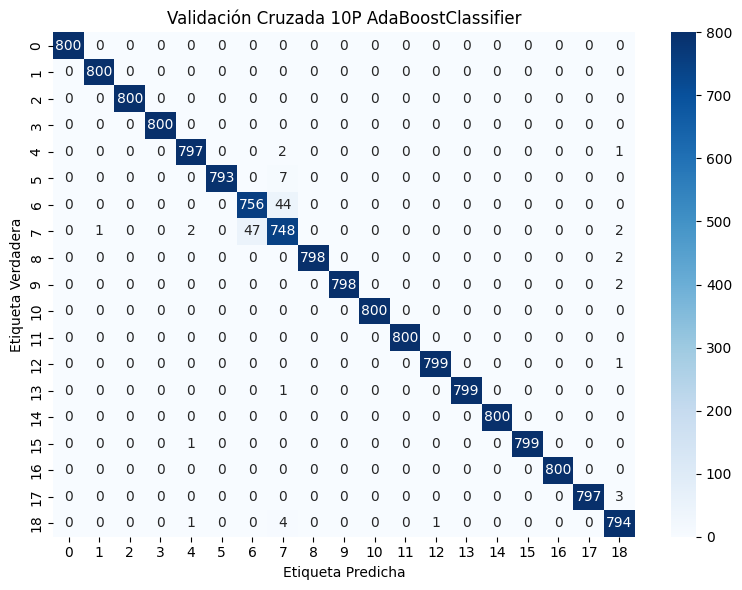

In [27]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada  = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_results = pipelinear_crossvalidation(ada, X, y_encoded)

**6 EL OTRO MÉTODO**

Puntuaciones (F1-macro):
  0.98999  0.99407  0.99143  0.99069  0.98951
  0.99145  0.99539  0.99014  0.99277  0.99473

Estadísticas de F1-macro:
Media:       0.99202
Mediana:     0.99144
Desvío:      0.00200
Mínimo:      0.98951
Máximo:      0.99539

Tiempos de entrenamiento (s):
  24.05806  24.52323  24.07670  24.27697  24.46108
  24.36991  24.38473  24.29533  24.00570  23.87967

Estadísticas de tiempos:
Media:       24.23314
Mediana:     24.28615
Desvío:      0.20381
Mínimo:      23.87967
Máximo:      24.52323


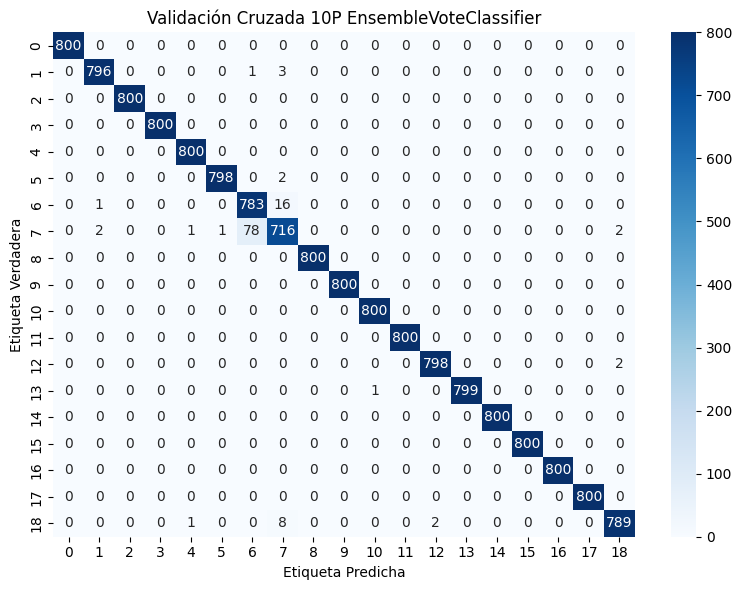

In [69]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('rf', clf2)])
pipe_nb = Pipeline([('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_results = pipelinear_crossvalidation(eclf, X, y_encoded)

#### 2.5.1.1. Resultados

In [72]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    # Extraemos la lista de folds (diccionarios con las métricas)
    folds = classifier_results[2]
    # Calculamos el agg_func sobre cada métrica a lo largo de todos los folds
    metrics = {
        "accuracy":        agg_func([f["accuracy"]        for f in folds]),
        "precision_macro": agg_func([f["precision_macro"] for f in folds]),
        "recall_macro":    agg_func([f["recall_macro"]    for f in folds]),
        "f1_macro":        agg_func([f["f1_macro"]        for f in folds]),
    }
    return metrics

# Obtenemos los resultados por clasificador
nb_metrics     = compute_metrics(nb_results)
lr_metrics     = compute_metrics(lr_results)
percep_metrics = compute_metrics(percep_results)
rf_metrics     = compute_metrics(rf_results)
ada_metrics    = compute_metrics(ada_results)
eclf_metrics   = compute_metrics(eclf_results)

# Crear un diccionario con los resultados
all_metrics = {
    "Naive Bayes":          nb_metrics,
    "Regresión Logística":  lr_metrics,
    "Perceptron":           percep_metrics,
    "Random Forest":        rf_metrics,
    "AdaBoost":             ada_metrics,
    "Voting":               eclf_metrics
}

# Crear el DataFrame y redondear a cinco decimales
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index").round(5)

print(df_metrics)


                     accuracy  precision_macro  recall_macro  f1_macro
Naive Bayes           0.96026          0.96185       0.96026   0.95994
Regresión Logística   0.99362          0.99371       0.99362   0.99361
Perceptron            0.99046          0.99084       0.99046   0.99048
Random Forest         0.99546          0.99553       0.99546   0.99546
AdaBoost              0.99197          0.99222       0.99197   0.99200
Voting                0.99204          0.99236       0.99204   0.99202


In [73]:
import numpy as np
from scipy.stats import wilcoxon

# Suponiendo que ya cargaste tus resultados en estas variables:
# Cada una es una tupla: (f1_array, tiempo_array, lista_de_dicts)
# donde lista_de_dicts[i]['f1_macro'] es el F1 para la i-ésima iteración.

# Ejemplo:
# nb_results     = (array([...]), array([...]), [{'f1_macro': ..., ...}, ...])
# lr_results     = ...
# percep_results = ...
# rf_results     = ...
# ada_results    = ...

# 1) Extraer arrays de F1-macro de cada clasificador
nb_f1     = np.array([d['f1_macro'] for d in nb_results[2]])
lr_f1     = np.array([d['f1_macro'] for d in lr_results[2]])
percep_f1 = np.array([d['f1_macro'] for d in percep_results[2]])
rf_f1     = np.array([d['f1_macro'] for d in rf_results[2]])
ada_f1    = np.array([d['f1_macro'] for d in ada_results[2]])
eclf_f1   = np.array([d['f1_macro'] for d in eclf_results[2]])

# 2) Calcular la media de F1 por iteración para cada grupo
f1_normales = np.mean(np.vstack([nb_f1, lr_f1, percep_f1]), axis=0)
f1_votacion = np.mean(np.vstack([rf_f1, ada_f1, eclf_f1]), axis=0)

# 3) Test de Wilcoxon signed-rank
statistic, p_value = wilcoxon(f1_normales, f1_votacion)

print(f"Wilcoxon statistic: {statistic:.4f}")
print(f"p-value:           {p_value:.4f}")

# 4) Interpretación rápida
alpha = 0.05
if p_value < alpha:
    print("→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos")
else:
    print("→ p ≥ 0.05: no hay evidencia de diferencia significativa")


Wilcoxon statistic: 0.0000
p-value:           0.0020
→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos


In [31]:
import numpy as np
from scipy.stats import wilcoxon

# 1) Extraer F1-macro como antes
nb_f1     = np.array([d['f1_macro'] for d in nb_results[2]])
lr_f1     = np.array([d['f1_macro'] for d in lr_results[2]])
percep_f1 = np.array([d['f1_macro'] for d in percep_results[2]])
rf_f1     = np.array([d['f1_macro'] for d in rf_results[2]])
ada_f1    = np.array([d['f1_macro'] for d in ada_results[2]])

# 2) Calcular media por iteración de cada grupo
f1_normales = np.mean(np.vstack([nb_f1, lr_f1, percep_f1]), axis=0)
f1_votacion = np.mean(np.vstack([rf_f1, ada_f1]), axis=0)

# 3) Estadísticas descriptivas
mean_normales = np.mean(f1_normales)
mean_votacion = np.mean(f1_votacion)
print(f"Media F1 (normales):    {mean_normales:.4f}")
print(f"Media F1 (votación):    {mean_votacion:.4f}")

# 4) ¿En cuántas iteraciones uno > otro?
gt = np.sum(f1_votacion > f1_normales)
lt = np.sum(f1_votacion < f1_normales)
eq = np.sum(f1_votacion == f1_normales)
print(f"\nIteraciones en que votación > normales: {gt}/10")
print(f"Iteraciones en que votación < normales: {lt}/10")
print(f"Iteraciones iguales:                   {eq}/10")

# 5) Test de Wilcoxon (no paramétrico)
statistic, p_value = wilcoxon(f1_normales, f1_votacion)
print(f"\nWilcoxon statistic: {statistic:.4f}, p-value: {p_value:.4f}")

# 6) Interpretación
alpha = 0.05
if p_value < alpha:
    print("→ p < 0.05: diferencia SIGNIFICATIVA")
else:
    print("→ p ≥ 0.05: sin evidencia de diferencia significativa")


Media F1 (normales):    0.9813
Media F1 (votación):    0.9939

Iteraciones en que votación > normales: 10/10
Iteraciones en que votación < normales: 0/10
Iteraciones iguales:                   0/10

Wilcoxon statistic: 0.0000, p-value: 0.0020
→ p < 0.05: diferencia SIGNIFICATIVA


### 2.5.2. LOSO

#### 2.5.2.1. Pieplinear: LOSO

In [32]:
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso(model, X, y, groups, n_splits=8):
    """
    Ajusta un pipeline (escalador + modelo) con CV por grupos (GroupKFold).
    X: features, y: etiquetas, groups: vector de grupos.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_groups/
    con nombre "Validación Cruzada Grupos {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + GroupKFold
    pipe = make_pipeline(StandardScaler(), model)
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(pipe, X, y_enc, groups=groups, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base = f"Validación Cruzada Grupos {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores


#### 2.5.2.2. Entrenar

Gaussian NB

Puntuaciones (F1-macro):
  0.64524  0.89994  0.94893  0.90550  0.75063
  0.86867  0.94647  0.94422

Estadísticas de F1-macro:
Media:       0.86370
Mediana:     0.90272
Desvío:      0.10259
Mínimo:      0.64524
Máximo:      0.94893

Tiempos de entrenamiento (s):
  0.22022  0.20703  0.20644  0.21339  0.20703
  0.22022  0.19965  0.22022

Estadísticas de tiempos:
Media:       0.21177
Mediana:     0.21021
Desvío:      0.00739
Mínimo:      0.19965
Máximo:      0.22022


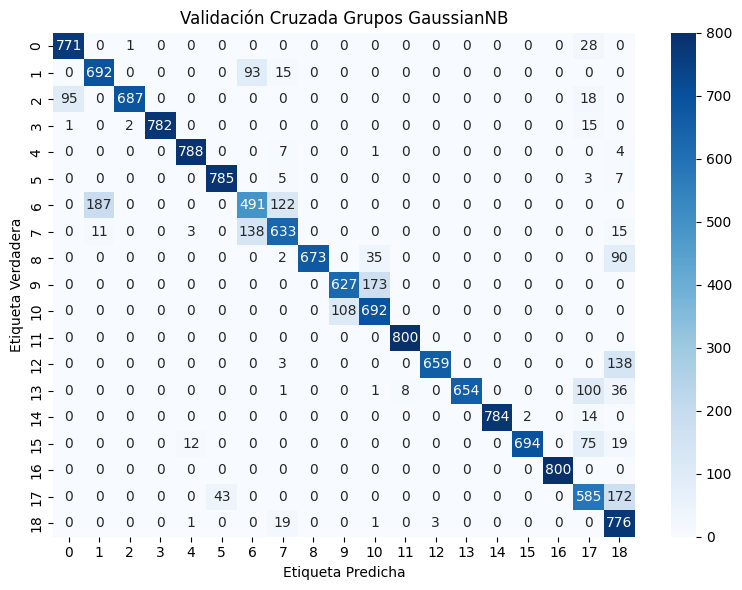

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
model = GaussianNB()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
nb_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

2 Logistic Regression

Puntuaciones (F1-macro):
  0.88322  0.95326  0.91127  0.87785  0.90107
  0.97102  0.95173  0.96364

Estadísticas de F1-macro:
Media:       0.92663
Mediana:     0.93150
Desvío:      0.03506
Mínimo:      0.87785
Máximo:      0.97102

Tiempos de entrenamiento (s):
  1.50257  1.85131  1.92680  1.62608  1.70392
  1.75424  1.80485  1.99219

Estadísticas de tiempos:
Media:       1.77024
Mediana:     1.77955
Desvío:      0.14943
Mínimo:      1.50257
Máximo:      1.99219


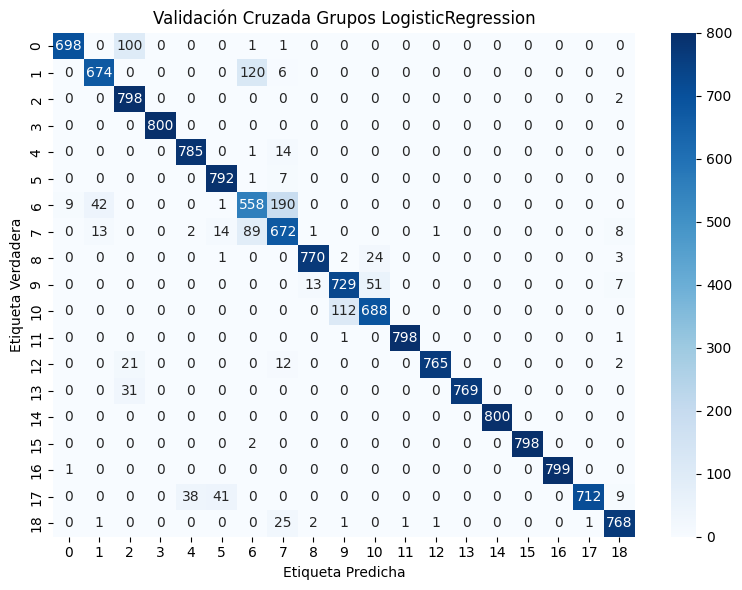

In [34]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
lr_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


3 MLP

Puntuaciones (F1-macro):
  0.83708  0.91629  0.84605  0.92052  0.82890
  0.91113  0.94136  0.81480

Estadísticas de F1-macro:
Media:       0.87702
Mediana:     0.87859
Desvío:      0.04674
Mínimo:      0.81480
Máximo:      0.94136

Tiempos de entrenamiento (s):
  2.13812  1.85021  2.13545  2.02552  2.01438
  2.12480  2.20916  1.91688

Estadísticas de tiempos:
Media:       2.05182
Mediana:     2.07516
Desvío:      0.11482
Mínimo:      1.85021
Máximo:      2.20916


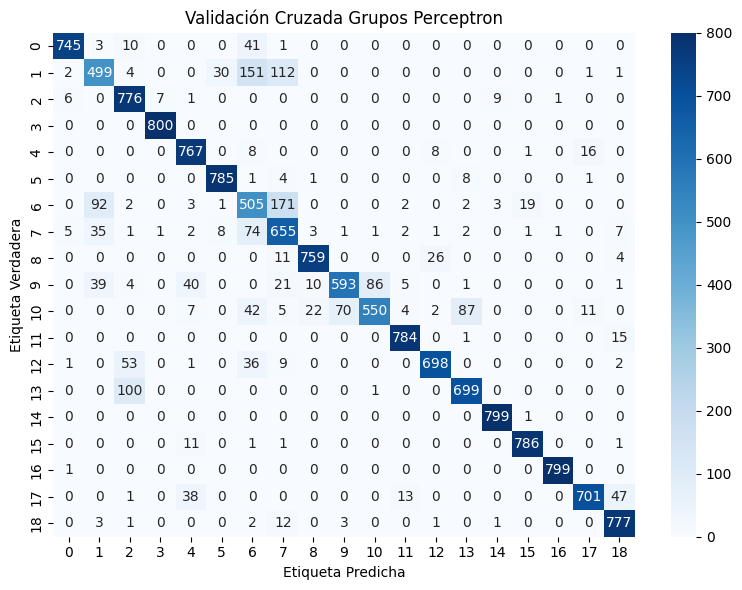

In [35]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import Perceptron
model = Perceptron()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
mlp_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Random Forest

Puntuaciones (F1-macro):
  0.88080  0.94211  0.95022  0.96995  0.91301
  0.92654  0.94741  0.90189

Estadísticas de F1-macro:
Media:       0.92899
Mediana:     0.93433
Desvío:      0.02729
Mínimo:      0.88080
Máximo:      0.96995

Tiempos de entrenamiento (s):
  18.61674  18.88562  19.00368  19.19593  19.30658
  18.87734  18.90370  18.84654

Estadísticas de tiempos:
Media:       18.95452
Mediana:     18.89466
Desvío:      0.20115
Mínimo:      18.61674
Máximo:      19.30658


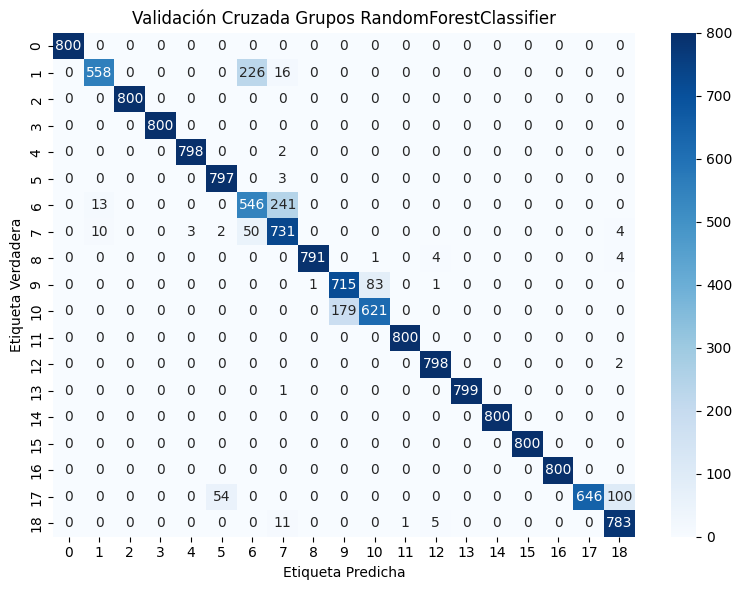

In [36]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
rf_loso = pipelinear_loso(
    model=rf,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


5 AdaBoost

Puntuaciones (F1-macro):
  0.71143  0.85761  0.89573  0.88426  0.83853
  0.86234  0.89791  0.87861

Estadísticas de F1-macro:
Media:       0.85330
Mediana:     0.87047
Desvío:      0.05683
Mínimo:      0.71143
Máximo:      0.89791

Tiempos de entrenamiento (s):
  208.80011  210.16985  211.48965  212.09967  210.34423
  210.29506  210.40507  210.00562

Estadísticas de tiempos:
Media:       210.45116
Mediana:     210.31965
Desvío:      0.92450
Mínimo:      208.80011
Máximo:      212.09967


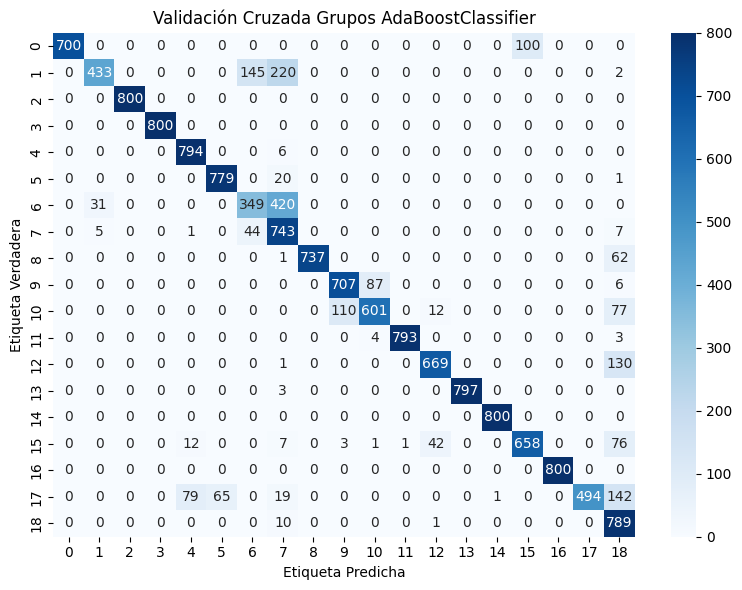

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1) Features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

base_estimator = DecisionTreeClassifier(max_depth=4)

model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

# 4) Validación LOSO
n_splits = groups.nunique()

ada_loso = pipelinear_loso(
    model=model,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=n_splits
)


**6 Voting con diferentes Features**

Puntuaciones (F1-macro):
  0.84058  0.97176  0.96608  0.96586  0.89053
  0.90802  0.98365  0.97550

Estadísticas de F1-macro:
Media:       0.93775
Mediana:     0.96597
Desvío:      0.04853
Mínimo:      0.84058
Máximo:      0.98365

Tiempos de entrenamiento (s):
  21.69872  22.21883  22.39447  22.35073  22.65420
  22.40520  22.13720  22.76717

Estadísticas de tiempos:
Media:       22.32831
Mediana:     22.37260
Desvío:      0.30710
Mínimo:      21.69872
Máximo:      22.76717


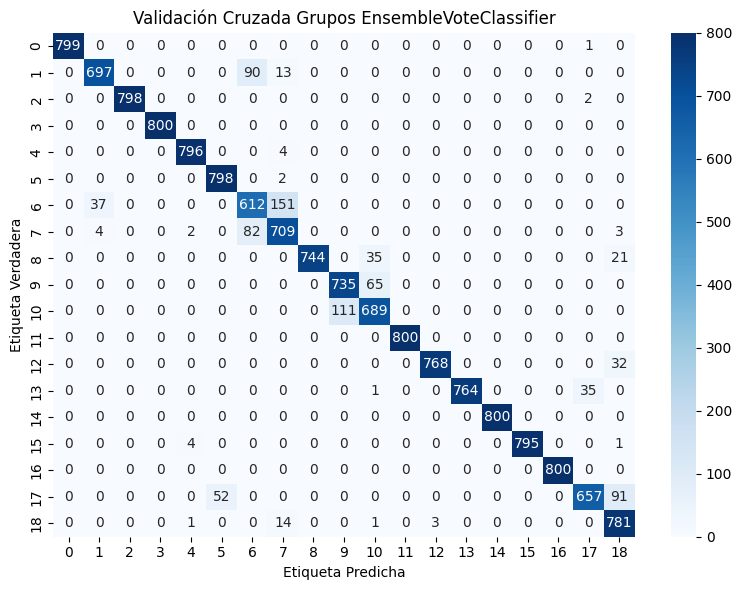

In [64]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('rf', clf2)])
pipe_nb = Pipeline([('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_loso = pipelinear_loso(eclf, X, y_encoded, groups=groups)

In [75]:
import pandas as pd
import numpy as np

def compute_metrics(results, agg_func=np.mean):
    """
    Si `results` es una tupla (X, Y, folds) donde folds es lista de dicts,
    calcula el promedio de accuracy, precision_macro, recall_macro y f1_macro.
    Si `results` es un array o tupla cuyo primer elemento es un array de f1,
    calcula estadísticas: media, mediana, desviación, mínimo y máximo.
    """
    # Caso lista de dicts (LOS-O folds)
    if isinstance(results, tuple) and len(results) == 3 and isinstance(results[2], list):
        folds = results[2]
        return {
            "accuracy":        agg_func([f["accuracy"]        for f in folds]),
            "precision_macro": agg_func([f["precision_macro"] for f in folds]),
            "recall_macro":    agg_func([f["recall_macro"]    for f in folds]),
            "f1_macro":        agg_func([f["f1_macro"]        for f in folds]),
        }

    # Caso array de F1 (o tupla cuyo primer elemento es ese array)
    # Asumimos que el array con las puntuaciones de F1 está en results directamente o en results[0]
    arr = None
    if isinstance(results, (list, np.ndarray)):
        arr = np.array(results)
    elif isinstance(results, tuple) and len(results) >= 1:
        arr = np.array(results[0])
    else:
        raise ValueError(f"Formato de resultados no soportado: {type(results)}")

    return {
        "f1_mean":   np.mean(arr),
        "f1_median": np.median(arr),
        "f1_std":    np.std(arr, ddof=1),
        "f1_min":    np.min(arr),
        "f1_max":    np.max(arr),
    }


# Ejemplo de uso para todos los clasificadores
nb_metrics     = compute_metrics(nb_loso)
lr_metrics     = compute_metrics(lr_loso)
percep_metrics = compute_metrics(mlp_loso)
rf_metrics     = compute_metrics(rf_loso)   
ada_metrics    = compute_metrics(ada_loso)

# Combinas los resultados en un DataFrame
all_metrics = {
    "Naive Bayes":          nb_metrics,
    "Regresión Logística":  lr_metrics,
    "Perceptron":           percep_metrics,
    "Random Forest":        rf_metrics,
    "AdaBoost":             ada_metrics,
    "Voting":               eclf_metrics
}

df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index").round(5)
print(df_metrics)


                     accuracy  precision_macro  recall_macro  f1_macro
Naive Bayes           0.87980          0.88335       0.87980   0.86370
Regresión Logística   0.93243          0.94194       0.93243   0.92663
Perceptron            0.88664          0.91372       0.88664   0.87702
Random Forest         0.93737          0.94076       0.93737   0.92899
AdaBoost              0.87125          0.87633       0.87125   0.85330
Voting                0.99204          0.99236       0.99204   0.99202


In [74]:
import numpy as np
from scipy.stats import wilcoxon

# Suponiendo que tus variables *_loso tienen la misma estructura:
# Cada una es una tupla: (f1_array, tiempo_array, lista_de_dicts)
# donde lista_de_dicts[i]['f1_macro'] es el F1 de la i-ésima iteración LO-SO.

# 1) Extraer arrays de F1-macro de cada clasificador LO-SO
nb_f1_loso   = np.array([d['f1_macro'] for d in nb_loso[2]])
lr_f1_loso   = np.array([d['f1_macro'] for d in lr_loso[2]])
mlp_f1_loso  = np.array([d['f1_macro'] for d in mlp_loso[2]])
rf_f1_loso   = np.array([d['f1_macro'] for d in rf_loso[2]])
ada_f1_loso  = np.array([d['f1_macro'] for d in ada_loso[2]])
eclf_f1_loso = np.array([d['f1_macro'] for d in eclf_loso[2]])

# 2) Calcular la media de F1 por iteración para cada grupo
#    - Grupo “normales”: NB, LR, MLP
#    - Grupo “votación”: RF, ADA
f1_normales_loso = np.mean(np.vstack([nb_f1_loso, lr_f1_loso, mlp_f1_loso]), axis=0)
f1_votacion_loso = np.mean(np.vstack([rf_f1_loso, ada_f1_loso, eclf_f1_loso]), axis=0)

# 3) Estadísticas descriptivas
mean_normales_loso = np.mean(f1_normales_loso)
mean_votacion_loso = np.mean(f1_votacion_loso)

print(f"Media F1 LO-SO (normales):    {mean_normales_loso:.4f}")
print(f"Media F1 LO-SO (votación):    {mean_votacion_loso:.4f}")

# 4) Conteo de pliegues donde un grupo supera al otro
gt_loso = np.sum(f1_votacion_loso > f1_normales_loso)
lt_loso = np.sum(f1_votacion_loso < f1_normales_loso)
eq_loso = np.sum(f1_votacion_loso == f1_normales_loso)

print(f"\nIteraciones LO-SO donde votación > normales: {gt_loso}/{len(f1_normales_loso)}")
print(f"Iteraciones LO-SO donde votación < normales: {lt_loso}/{len(f1_normales_loso)}")
print(f"Iteraciones LO-SO iguales:                  {eq_loso}/{len(f1_normales_loso)}")

# 5) Test de Wilcoxon signed-rank no paramétrico
statistic_loso, p_value_loso = wilcoxon(f1_normales_loso, f1_votacion_loso)
print(f"\nWilcoxon LO-SO statistic: {statistic_loso:.4f}, p-value: {p_value_loso:.4f}")

# 6) Interpretación
alpha = 0.05
if p_value_loso < alpha:
    print("→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos LO-SO")
else:
    print("→ p ≥ 0.05: sin evidencia de diferencia significativa LO-SO")


Media F1 LO-SO (normales):    0.8891
Media F1 LO-SO (votación):    0.9067

Iteraciones LO-SO donde votación > normales: 6/8
Iteraciones LO-SO donde votación < normales: 2/8
Iteraciones LO-SO iguales:                  0/8

Wilcoxon LO-SO statistic: 6.0000, p-value: 0.1094
→ p ≥ 0.05: sin evidencia de diferencia significativa LO-SO


# PCA

## 1. PCA con 10-fold CV

In [76]:
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_crossvalidation_pca(model, X, y):
    """
    Pipeline con estandarización + PCA (95% varianza explicada) + modelo.
    Imprime cuántas features había antes y cuántas retiene PCA, y luego
    evalúa usando validación cruzada estratificada 10-fold.
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_encoded = y
        etiquetas = np.unique(y)

    # ----------------------------------------------------
    # → NUEVO: calcular nº de features antes/después de PCA
    # ----------------------------------------------------
    scaler_temp = StandardScaler()
    X_scaled = scaler_temp.fit_transform(X)
    pca_temp = PCA(n_components=0.95)
    pca_temp.fit(X_scaled)
    n_before = X.shape[1]
    n_after  = pca_temp.n_components_
    print(f"Features originales: {n_before}")
    print(f"Features tras PCA (95% varianza): {n_after}\n")

    # 1) Scorers
    precision_macro_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_macro_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_macro_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy_scorer    = 'accuracy'

    # 2) Pipeline con PCA
    scaler = StandardScaler()
    pca    = PCA(n_components=0.95)
    pipe   = make_pipeline(scaler, pca, model)

    # 3) Validación cruzada
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_encoded,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 4) Recoger métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(cv.get_n_splits())
    ]

    # 5) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 6) Impresión de resultados
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for etiqueta, valor in stats_scores.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for etiqueta, valor in stats_times.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    # 7) Matriz de confusión out-of-fold
    y_pred = cross_val_predict(pipe, X, y_encoded, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_encoded, y_pred)

    # 8) Guardar y mostrar la matriz
    output_folder = os.path.join("resultados_dsaa", "crossval_10k")
    os.makedirs(output_folder, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada 10 Folds {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    base_name = f"Validación Cruzada 10-Folds {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base_name}_1080p.png"),
                dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base_name}_4k.png"),
                dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base_name}.svg"),
                bbox_inches='tight')

    return scores, times, all_scores


1 Naive Bayes PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.93881  0.95108  0.95356  0.95291  0.94216
  0.95577  0.95705  0.94092  0.95620  0.95528

Estadísticas de F1-macro:
Media:       0.95037
Mediana:     0.95323
Desvío:      0.00663
Mínimo:      0.93881
Máximo:      0.95705

Tiempos de entrenamiento (s):
  0.36428  0.37028  0.35476  0.37383  0.35476
  0.36729  0.35676  0.35476  0.37483  0.37130

Estadísticas de tiempos:
Media:       0.36428
Mediana:     0.36578
Desvío:      0.00791
Mínimo:      0.35476
Máximo:      0.37483


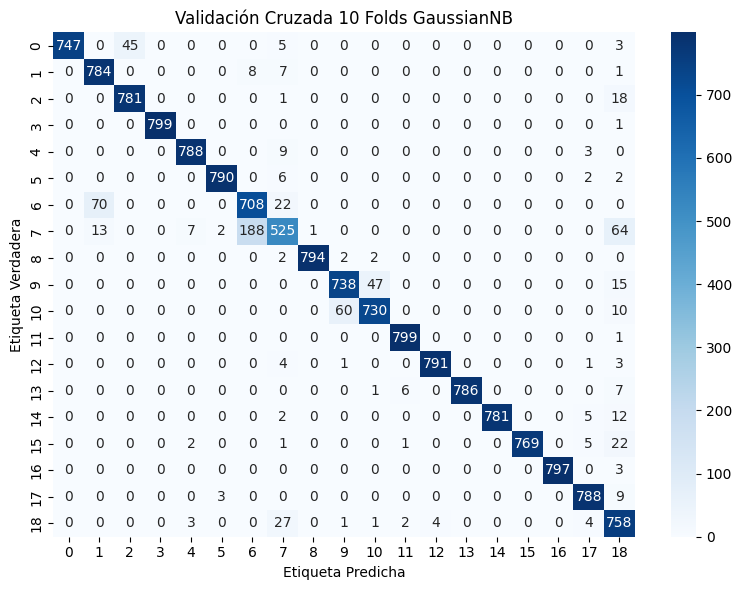

In [77]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results_pca = pipelinear_crossvalidation_pca(nb, X, y_encoded)

2 Logistic Regression PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.98791  0.99272  0.99211  0.98946  0.98951
  0.99146  0.99206  0.99079  0.99474  0.98941

Estadísticas de F1-macro:
Media:       0.99102
Mediana:     0.99113
Desvío:      0.00190
Mínimo:      0.98791
Máximo:      0.99474

Tiempos de entrenamiento (s):
  3.50911  3.35807  2.74199  3.18930  3.08763
  3.54715  2.38436  3.18830  3.30149  3.54215

Estadísticas de tiempos:
Media:       3.18495
Mediana:     3.24540
Desvío:      0.35413
Mínimo:      2.38436
Máximo:      3.54715


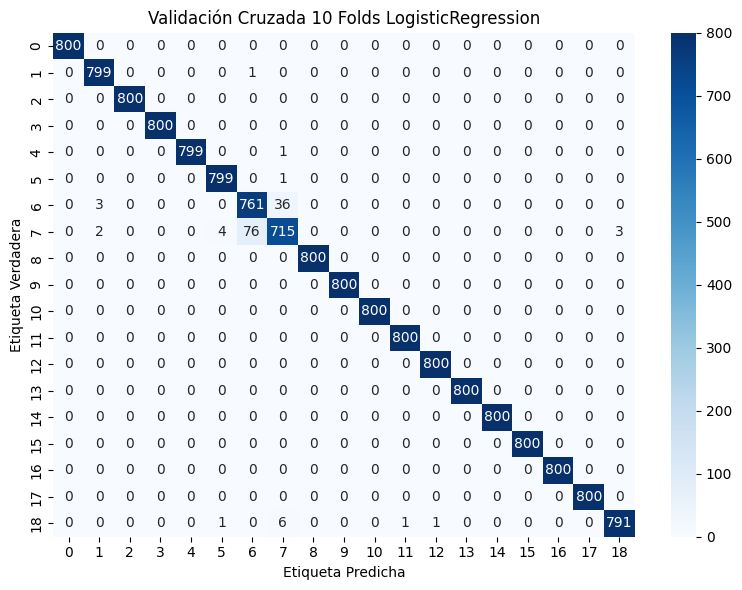

In [79]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results_pca = pipelinear_crossvalidation_pca(lr, X, y_encoded)

3 MLP PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.97844  0.96689  0.97643  0.98422  0.97760
  0.97943  0.97872  0.97863  0.98306  0.98465

Estadísticas de F1-macro:
Media:       0.97881
Mediana:     0.97867
Desvío:      0.00481
Mínimo:      0.96689
Máximo:      0.98465

Tiempos de entrenamiento (s):
  1.66203  1.55620  1.58578  1.64623  1.67304
  1.52004  1.58385  1.55823  1.71472  1.71274

Estadísticas de tiempos:
Media:       1.62129
Mediana:     1.61600
Desvío:      0.06571
Mínimo:      1.52004
Máximo:      1.71472


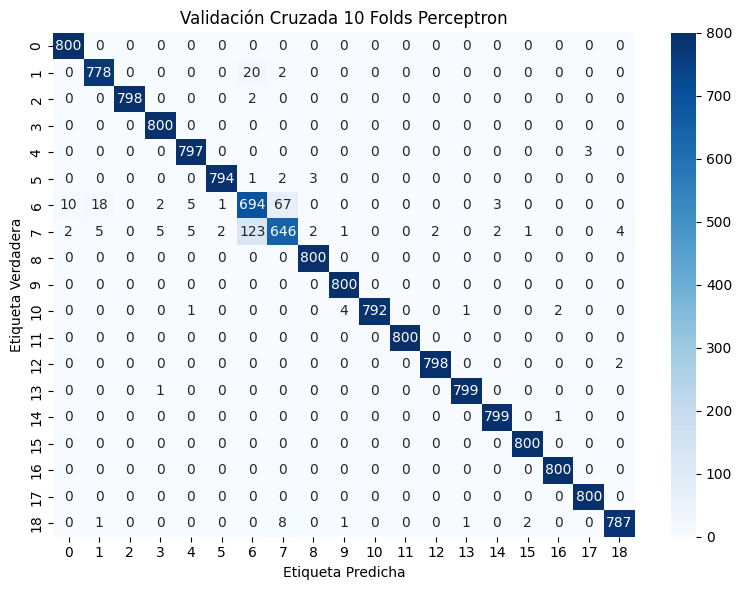

In [80]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results_pca = pipelinear_crossvalidation_pca(perceptron, X, y_encoded)

4 Random Forest PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.98239  0.98808  0.98881  0.98876  0.98221
  0.98541  0.98869  0.98202  0.98467  0.98472

Estadísticas de F1-macro:
Media:       0.98558
Mediana:     0.98507
Desvío:      0.00269
Mínimo:      0.98202
Máximo:      0.98881

Tiempos de entrenamiento (s):
  16.09409  16.25935  16.08657  16.02493  15.96981
  16.09057  16.22005  16.06404  16.07306  15.92127

Estadísticas de tiempos:
Media:       16.08037
Mediana:     16.07981
Desvío:      0.09633
Mínimo:      15.92127
Máximo:      16.25935


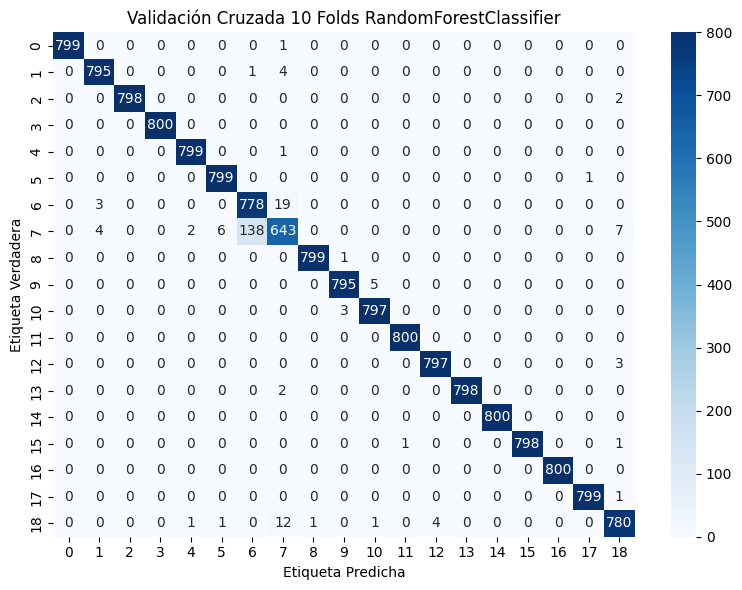

In [81]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results_pca = pipelinear_crossvalidation_pca(rf, X, y_encoded)

5 AdaBoost PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.97036  0.97046  0.97384  0.97764  0.96429
  0.97646  0.97160  0.97336  0.96982  0.96969

Estadísticas de F1-macro:
Media:       0.97175
Mediana:     0.97103
Desvío:      0.00362
Mínimo:      0.96429
Máximo:      0.97764

Tiempos de entrenamiento (s):
  97.78901  98.14234  98.01129  97.12747  97.61444
  98.24764  98.28232  97.52281  97.76496  97.81304

Estadísticas de tiempos:
Media:       97.83153
Mediana:     97.80103
Desvío:      0.33911
Mínimo:      97.12747
Máximo:      98.28232


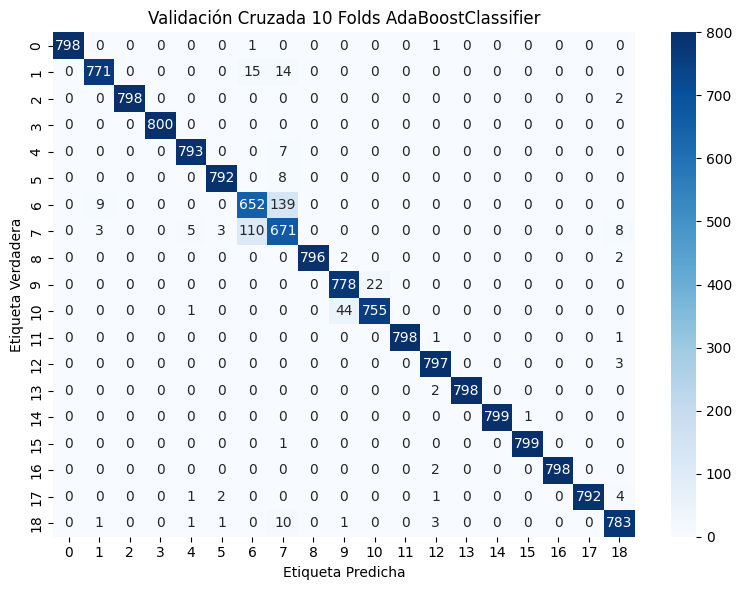

In [82]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada  = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_results_pca = pipelinear_crossvalidation_pca(ada, X, y_encoded)

6 Voting PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.98161  0.98528  0.98671  0.98529  0.98147
  0.98410  0.99002  0.97935  0.98743  0.98655

Estadísticas de F1-macro:
Media:       0.98478
Mediana:     0.98528
Desvío:      0.00305
Mínimo:      0.97935
Máximo:      0.99002

Tiempos de entrenamiento (s):
  19.82851  19.54743  18.71560  19.46651  19.36153
  19.67529  18.65940  19.37165  19.59900  19.87423

Estadísticas de tiempos:
Media:       19.40992
Mediana:     19.50697
Desvío:      0.39601
Mínimo:      18.65940
Máximo:      19.87423


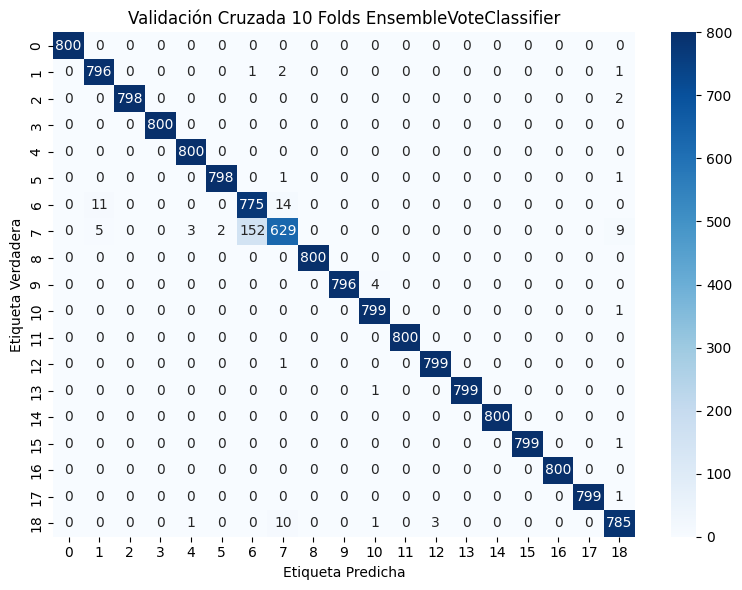

In [83]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('rf', clf2)])
pipe_nb = Pipeline([('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_results_pca = pipelinear_crossvalidation_pca(eclf, X, y_encoded)

In [84]:
import pandas as pd
import numpy as np

def compute_metrics(results, agg_func=np.mean):
    """
    Si `results` es una tupla (X, Y, folds) donde folds es lista de dicts,
    calcula el promedio de accuracy, precision_macro, recall_macro y f1_macro.
    Si `results` es un array o tupla cuyo primer elemento es un array de f1,
    calcula estadísticas: media, mediana, desviación, mínimo y máximo.
    """
    # Caso lista de dicts (LOS-O folds)
    if isinstance(results, tuple) and len(results) == 3 and isinstance(results[2], list):
        folds = results[2]
        return {
            "accuracy":        agg_func([f["accuracy"]        for f in folds]),
            "precision_macro": agg_func([f["precision_macro"] for f in folds]),
            "recall_macro":    agg_func([f["recall_macro"]    for f in folds]),
            "f1_macro":        agg_func([f["f1_macro"]        for f in folds]),
        }

    # Caso array de F1 (o tupla cuyo primer elemento es ese array)
    if isinstance(results, (list, np.ndarray)):
        arr = np.array(results)
    elif isinstance(results, tuple) and len(results) >= 1:
        arr = np.array(results[0])
    else:
        raise ValueError(f"Formato de resultados no soportado: {type(results)}")

    return {
        "f1_mean":   np.mean(arr),
        "f1_median": np.median(arr),
        "f1_std":    np.std(arr, ddof=1),
        "f1_min":    np.min(arr),
        "f1_max":    np.max(arr),
    }


# Cálculo de métricas para cada clasificador (con sufijo _pca)
nb_metrics_pca     = compute_metrics(nb_results_pca)
lr_metrics_pca     = compute_metrics(lr_results_pca)
percep_metrics_pca = compute_metrics(percep_results_pca)
rf_metrics_pca     = compute_metrics(rf_results_pca)
ada_metrics_pca    = compute_metrics(ada_results_pca)
eclf_metrics_pca   = compute_metrics(eclf_results_pca)

# Combinar en un diccionario
all_metrics_pca = {
    "Naive Bayes":          nb_metrics_pca,
    "Regresión Logística":  lr_metrics_pca,
    "Perceptron":           percep_metrics_pca,
    "Random Forest":        rf_metrics_pca,
    "AdaBoost":             ada_metrics_pca,
}

# Crear el DataFrame y redondear a cinco decimales
df_metrics_pca = pd.DataFrame.from_dict(all_metrics_pca, orient="index").round(5)

print(df_metrics_pca)


                     accuracy  precision_macro  recall_macro  f1_macro
Naive Bayes           0.95086          0.95290       0.95086   0.95037
Regresión Logística   0.99105          0.99124       0.99105   0.99102
Perceptron            0.97908          0.98020       0.97908   0.97881
Random Forest         0.98572          0.98652       0.98572   0.98558
AdaBoost              0.97158          0.97241       0.97158   0.97175


In [85]:
import numpy as np
from scipy.stats import wilcoxon

# Suponiendo que tus variables *_pca tienen la misma estructura:
# Cada una es una tupla: (f1_array, tiempo_array, lista_de_dicts)
# donde lista_de_dicts[i]['f1_macro'] es el F1 de la i-ésima iteración con PCA.

# 1) Extraer arrays de F1-macro de cada clasificador con PCA
nb_f1_pca     = np.array([d['f1_macro'] for d in nb_results_pca[2]])
lr_f1_pca     = np.array([d['f1_macro'] for d in lr_results_pca[2]])
percep_f1_pca = np.array([d['f1_macro'] for d in percep_results_pca[2]])
rf_f1_pca     = np.array([d['f1_macro'] for d in rf_results_pca[2]])
ada_f1_pca    = np.array([d['f1_macro'] for d in ada_results_pca[2]])
eclf_f1_pca   = np.array([d['f1_macro'] for d in eclf_results_pca[2]])

# 2) Calcular la media de F1 por iteración para cada grupo
#    - Grupo “normales”: NB, LR, Perceptrón
#    - Grupo “votación”: RF, ADA
f1_normales_pca = np.mean(np.vstack([nb_f1_pca, lr_f1_pca, percep_f1_pca]), axis=0)
f1_votacion_pca = np.mean(np.vstack([rf_f1_pca, ada_f1_pca, eclf_f1_pca]), axis=0)

# 3) Estadísticas descriptivas
mean_normales_pca = np.mean(f1_normales_pca)
mean_votacion_pca = np.mean(f1_votacion_pca)

print(f"Media F1 PCA (normales):    {mean_normales_pca:.4f}")
print(f"Media F1 PCA (votación):    {mean_votacion_pca:.4f}")

# 4) Conteo de iteraciones donde un grupo supera al otro
gt_pca = np.sum(f1_votacion_pca > f1_normales_pca)
lt_pca = np.sum(f1_votacion_pca < f1_normales_pca)
eq_pca = np.sum(f1_votacion_pca == f1_normales_pca)

print(f"\nIteraciones PCA donde votación > normales: {gt_pca}/{len(f1_normales_pca)}")
print(f"Iteraciones PCA donde votación < normales: {lt_pca}/{len(f1_normales_pca)}")
print(f"Iteraciones PCA iguales:                  {eq_pca}/{len(f1_normales_pca)}")

# 5) Test de Wilcoxon signed-rank no paramétrico
statistic_pca, p_value_pca = wilcoxon(f1_normales_pca, f1_votacion_pca)
print(f"\nWilcoxon PCA statistic: {statistic_pca:.4f}, p-value: {p_value_pca:.4f}")

# 6) Interpretación
alpha = 0.05
if p_value_pca < alpha:
    print("→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos con PCA")
else:
    print("→ p ≥ 0.05: sin evidencia de diferencia significativa con PCA")


Media F1 PCA (normales):    0.9734
Media F1 PCA (votación):    0.9807

Iteraciones PCA donde votación > normales: 10/10
Iteraciones PCA donde votación < normales: 0/10
Iteraciones PCA iguales:                  0/10

Wilcoxon PCA statistic: 0.0000, p-value: 0.0020
→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos con PCA


## 2. PCA con Group Cross Validation

In [86]:
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso_pca(model, X, y, groups, n_splits=8):
    """
    Ajusta un pipeline (escalador + PCA al 95% de varianza + modelo)
    con CV por grupos (GroupKFold para leave-one-subject-out sobre 8 sujetos).
    X: features, y: etiquetas, groups: vector de grupos.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_groups_pca/
    con nombre "Validación Cruzada Grupos PCA {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # ----------------------------------------------------
    # → Cálculo de componentes antes/después de PCA al 95% 
    # ----------------------------------------------------
    scaler_temp = StandardScaler()
    X_scaled = scaler_temp.fit_transform(X)
    pca_temp = PCA(n_components=0.95)
    pca_temp.fit(X_scaled)
    n_before = X.shape[1]
    n_after  = pca_temp.n_components_
    print(f"Features originales: {n_before}")
    print(f"Features tras PCA (95% varianza): {n_after}\n")

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + PCA + GroupKFold
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95),
        model
    )
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(
        pipe, X, y_enc,
        groups=groups,
        cv=cv,
        n_jobs=-1
    )
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups_pca")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos PCA {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base = f"Validación Cruzada Grupos PCA {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.83807  0.83431  0.93284  0.82708  0.77221
  0.85295  0.93293  0.88176

Estadísticas de F1-macro:
Media:       0.85902
Mediana:     0.84551
Desvío:      0.05132
Mínimo:      0.77221
Máximo:      0.93293

Tiempos de entrenamiento (s):
  0.21309  0.21961  0.22713  0.20408  0.20208
  0.23013  0.19856  0.22661

Estadísticas de tiempos:
Media:       0.21516
Mediana:     0.21635
Desvío:      0.01168
Mínimo:      0.19856
Máximo:      0.23013


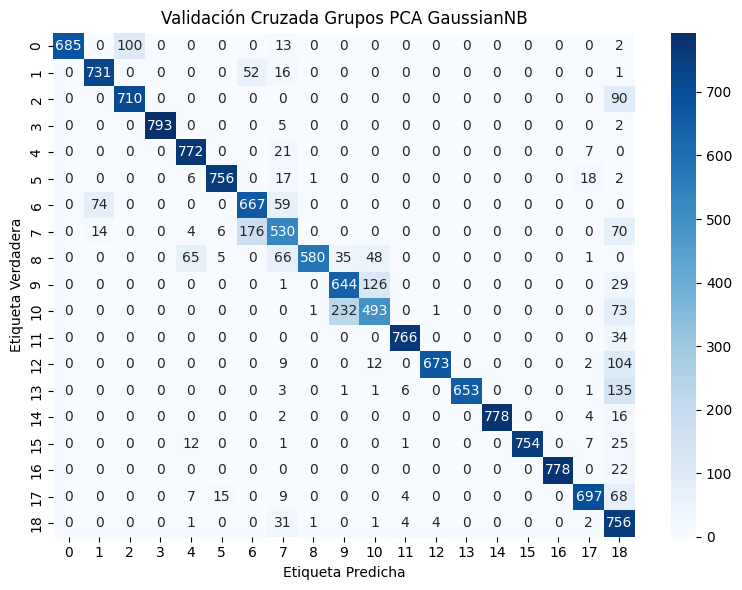

In [87]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
model = GaussianNB()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
nb_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.90854  0.93502  0.94555  0.93084  0.91662
  0.96324  0.92353  0.93379

Estadísticas de F1-macro:
Media:       0.93214
Mediana:     0.93231
Desvío:      0.01593
Mínimo:      0.90854
Máximo:      0.96324

Tiempos de entrenamiento (s):
  1.81278  1.61919  1.59067  1.97217  1.63423
  2.47418  2.30254  2.19127

Estadísticas de tiempos:
Media:       1.94963
Mediana:     1.89247
Desvío:      0.31915
Mínimo:      1.59067
Máximo:      2.47418


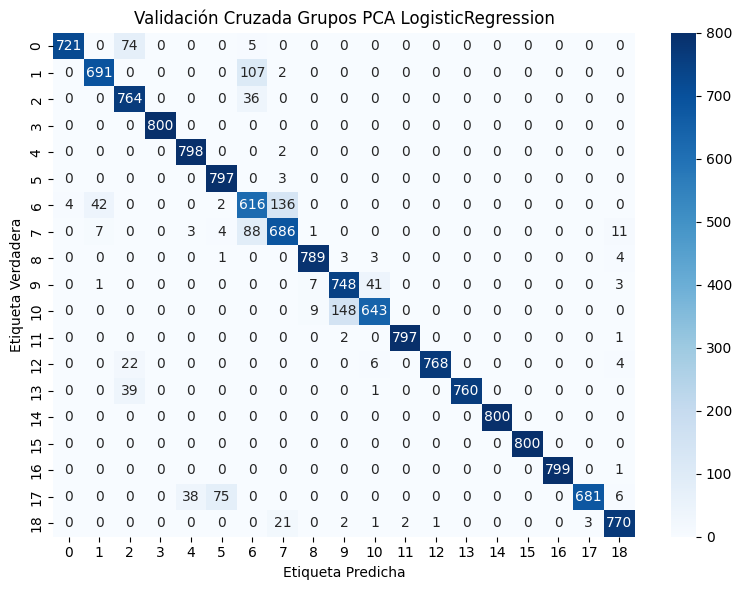

In [88]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
lr_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.84593  0.90137  0.89776  0.89837  0.78432
  0.88530  0.94227  0.85477

Estadísticas de F1-macro:
Media:       0.87626
Mediana:     0.89153
Desvío:      0.04452
Mínimo:      0.78432
Máximo:      0.94227

Tiempos de entrenamiento (s):
  1.13083  1.17946  1.22207  1.18758  1.20806
  1.16238  1.19647  1.14384

Estadísticas de tiempos:
Media:       1.17884
Mediana:     1.18352
Desvío:      0.02939
Mínimo:      1.13083
Máximo:      1.22207


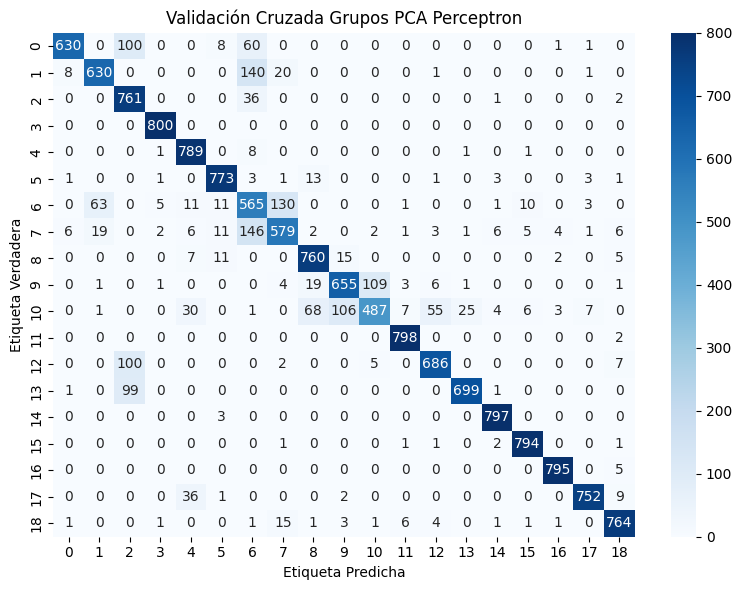

In [89]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import Perceptron
model = Perceptron()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
mlp_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Puntuaciones (F1-macro):
  0.99402  0.99605  0.99474  0.99671  0.99211
  0.99539  0.99934  0.99342  0.99539  0.99737

Estadísticas de F1-macro:
Media:       0.99545
Mediana:     0.99539
Desvío:      0.00197
Mínimo:      0.99211
Máximo:      0.99934

Tiempos de entrenamiento (s):
  23.33179  23.20414  23.46609  23.52120  23.19814
  23.15240  23.47466  23.54630  23.29274  23.57691

Estadísticas de tiempos:
Media:       23.37644
Mediana:     23.39894
Desvío:      0.15112
Mínimo:      23.15240
Máximo:      23.57691


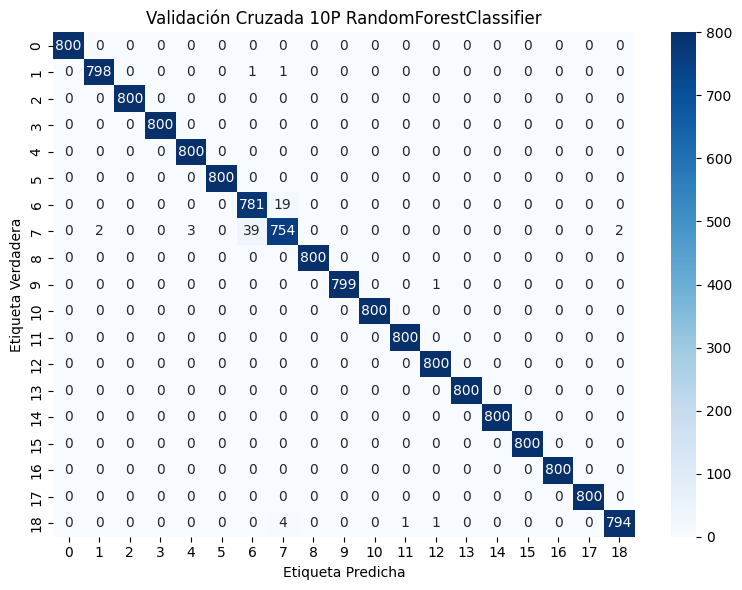

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.84345  0.92633  0.92766  0.83533  0.93174
  0.89769  0.93467  0.85835

Estadísticas de F1-macro:
Media:       0.89440
Mediana:     0.91201
Desvío:      0.03959
Mínimo:      0.83533
Máximo:      0.93467

Tiempos de entrenamiento (s):
  14.41048  14.42386  14.80149  14.66309  14.82302
  14.71531  14.48867  14.47212

Estadísticas de tiempos:
Media:       14.59975
Mediana:     14.57588
Desvío:      0.15941
Mínimo:      14.41048
Máximo:      14.82302


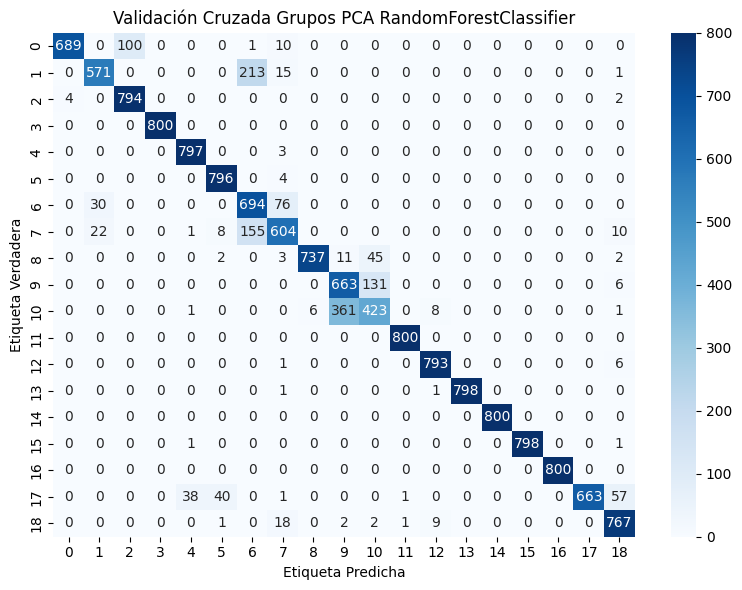

In [90]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
rf_loso_pca = pipelinear_loso_pca(
    model=rf,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.80436  0.93012  0.90175  0.83137  0.88490
  0.76240  0.87873  0.75536

Estadísticas de F1-macro:
Media:       0.84363
Mediana:     0.85505
Desvío:      0.06111
Mínimo:      0.75536
Máximo:      0.93012

Tiempos de entrenamiento (s):
  84.66378  84.86477  86.91601  86.49425  86.97716
  84.57615  86.10495  85.92292

Estadísticas de tiempos:
Media:       85.81500
Mediana:     86.01394
Desvío:      0.92756
Mínimo:      84.57615
Máximo:      86.97716


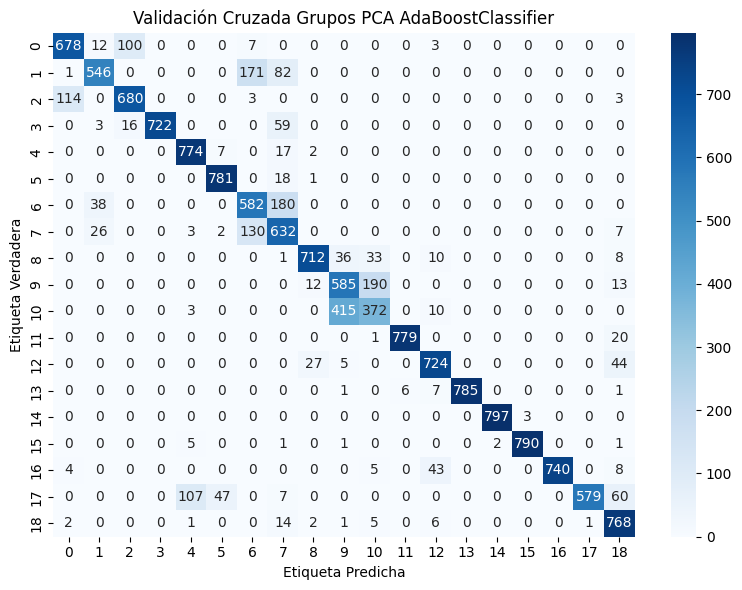

In [91]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1) Features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

base_estimator = DecisionTreeClassifier(max_depth=4)

model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

# 4) Validación LOSO
n_splits = groups.nunique()

ada_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=n_splits
)


### Voting

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.98161  0.98528  0.98671  0.98529  0.98147
  0.98410  0.99002  0.97935  0.98743  0.98655

Estadísticas de F1-macro:
Media:       0.98478
Mediana:     0.98528
Desvío:      0.00305
Mínimo:      0.97935
Máximo:      0.99002

Tiempos de entrenamiento (s):
  18.10017  17.96725  17.22286  17.85714  17.67585
  18.16479  17.08754  17.69287  17.98277  18.14471

Estadísticas de tiempos:
Media:       17.78960
Mediana:     17.91220
Desvío:      0.35681
Mínimo:      17.08754
Máximo:      18.16479


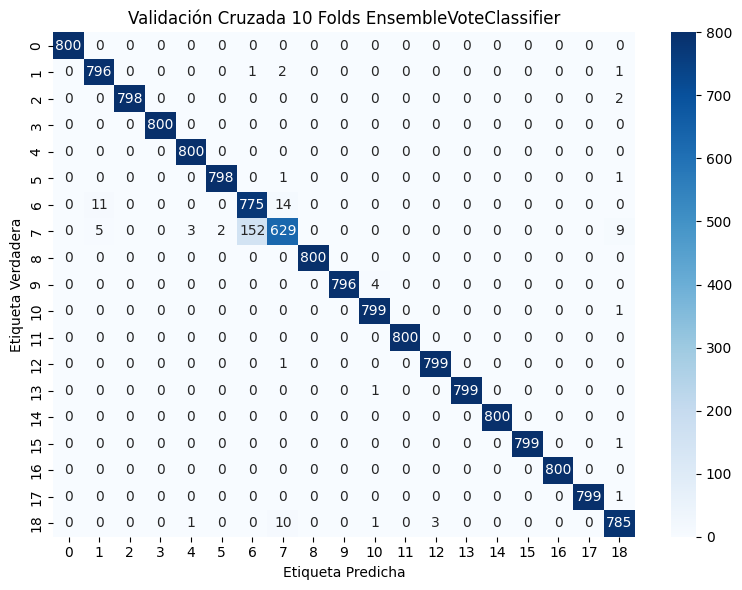

In [97]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('rf', clf2)])
pipe_nb = Pipeline([('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_loso_pca = pipelinear_crossvalidation_pca(eclf, X, y_encoded)

In [98]:
import pandas as pd
import numpy as np

def compute_metrics(results, agg_func=np.mean):
    """
    Si `results` es una tupla (X, Y, folds) donde folds es lista de dicts,
    calcula el promedio de accuracy, precision_macro, recall_macro y f1_macro.
    Si `results` es un array o tupla cuyo primer elemento es un array de f1,
    calcula estadísticas: media, mediana, desviación, mínimo y máximo.
    """
    # Caso lista de dicts (LOS-O folds)
    if isinstance(results, tuple) and len(results) == 3 and isinstance(results[2], list):
        folds = results[2]
        return {
            "accuracy":        agg_func([f["accuracy"]        for f in folds]),
            "precision_macro": agg_func([f["precision_macro"] for f in folds]),
            "recall_macro":    agg_func([f["recall_macro"]    for f in folds]),
            "f1_macro":        agg_func([f["f1_macro"]        for f in folds]),
        }
    # Caso array de F1 (o tupla cuyo primer elemento es ese array)
    elif isinstance(results, (list, np.ndarray)):
        arr = np.array(results)
        return {
            "f1_mean":   np.mean(arr),
            "f1_median": np.median(arr),
            "f1_std":    np.std(arr, ddof=1),
            "f1_min":    np.min(arr),
            "f1_max":    np.max(arr),
        }
    elif isinstance(results, tuple) and len(results) >= 1:
        arr = np.array(results[0])
        return {
            "f1_mean":   np.mean(arr),
            "f1_median": np.median(arr),
            "f1_std":    np.std(arr, ddof=1),
            "f1_min":    np.min(arr),
            "f1_max":    np.max(arr),
        }
    else:
        raise ValueError(f"Formato de resultados no soportado: {type(results)}")

# Cálculo de métricas para cada clasificador (con sufijo _pca)
nb_metrics_pca     = compute_metrics(nb_loso_pca)
lr_metrics_pca     = compute_metrics(lr_loso_pca)
percep_metrics_pca = compute_metrics(mlp_loso_pca)
rf_metrics_pca     = compute_metrics(rf_loso_pca)
ada_metrics_pca    = compute_metrics(ada_loso_pca)
eclf_metrics_pca   = compute_metrics(eclf_loso_pca)

# Combinar en un diccionario
all_metrics_pca = {
    "Naive Bayes":          nb_metrics_pca,
    "Regresión Logística":  lr_metrics_pca,
    "Perceptron":           percep_metrics_pca,
    "Random Forest":        rf_metrics_pca,
    "AdaBoost":             ada_metrics_pca,
    "Voting":               eclf_metrics_pca
}

# Crear el DataFrame y redondear a cinco decimales
df_metrics_pca = pd.DataFrame.from_dict(all_metrics_pca, orient="index").round(5)
print(df_metrics_pca)

                     accuracy  precision_macro  recall_macro  f1_macro
Naive Bayes           0.86947          0.89387       0.86947   0.85902
Regresión Logística   0.93605          0.94882       0.93605   0.93214
Perceptron            0.88908          0.90147       0.88908   0.87626
Random Forest         0.90382          0.91378       0.90382   0.89440
AdaBoost              0.85697          0.87466       0.85697   0.84363
Voting                0.98500          0.98619       0.98500   0.98478


In [ ]:
import numpy as np
from scipy.stats import wilcoxon

# Suponiendo que tus variables *_loso_pca tienen la misma estructura:
# Cada una es una tupla: (f1_array, tiempo_array, lista_de_dicts)
# donde lista_de_dicts[i]['f1_macro'] es el F1 de la i-ésima iteración LO-SO con PCA.

# 1) Extraer arrays de F1-macro de cada clasificador LO-SO con PCA
nb_f1_loso_pca   = np.array([d['f1_macro'] for d in nb_loso_pca[2]])
lr_f1_loso_pca   = np.array([d['f1_macro'] for d in lr_loso_pca[2]])
mlp_f1_loso_pca  = np.array([d['f1_macro'] for d in mlp_loso_pca[2]])
rf_f1_loso_pca   = np.array([d['f1_macro'] for d in rf_loso_pca[2]])
ada_f1_loso_pca  = np.array([d['f1_macro'] for d in ada_loso_pca[2]])
eclf_f1_loso_pca  = np.array([d['f1_macro'] for d in eclf_loso_pca[2]])

# 2) Calcular la media de F1 por iteración para cada grupo
#    - Grupo “normales”: NB, LR, MLP
#    - Grupo “votación”: RF, ADA
f1_normales_loso_pca = np.mean(
    np.vstack([nb_f1_loso_pca, lr_f1_loso_pca, mlp_f1_loso_pca]), axis=0
)
f1_votacion_loso_pca = np.mean(
    np.vstack([rf_f1_loso_pca, ada_f1_loso_pca, eclf_f1_loso_pca]), axis=0
)

# 3) Estadísticas descriptivas
mean_normales_loso_pca = np.mean(f1_normales_loso_pca)
mean_votacion_loso_pca = np.mean(f1_votacion_loso_pca)

print(f"Media F1 LO-SO PCA (normales):    {mean_normales_loso_pca:.4f}")
print(f"Media F1 LO-SO PCA (votación):    {mean_votacion_loso_pca:.4f}")

# 4) Conteo de iteraciones donde un grupo supera al otro
gt_loso_pca = np.sum(f1_votacion_loso_pca > f1_normales_loso_pca)
lt_loso_pca = np.sum(f1_votacion_loso_pca < f1_normales_loso_pca)
eq_loso_pca = np.sum(f1_votacion_loso_pca == f1_normales_loso_pca)

n_iters = len(f1_normales_loso_pca)
print(f"\nIteraciones LO-SO PCA donde votación > normales: {gt_loso_pca}/{n_iters}")
print(f"Iteraciones LO-SO PCA donde votación < normales: {lt_loso_pca}/{n_iters}")
print(f"Iteraciones LO-SO PCA iguales:                  {eq_loso_pca}/{n_iters}")

# 5) Test de Wilcoxon signed-rank no paramétrico
statistic_loso_pca, p_value_loso_pca = wilcoxon(
    f1_normales_loso_pca, f1_votacion_loso_pca
)
print(f"\nWilcoxon LO-SO PCA statistic: {statistic_loso_pca:.4f}, "
      f"p-value: {p_value_loso_pca:.4f}")

# 6) Interpretación
alpha = 0.05
if p_value_loso_pca < alpha:
    print("→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos LO-SO con PCA")
else:
    print("→ p ≥ 0.05: sin evidencia de diferencia significativa LO-SO con PCA")


Media F1 LO-SO PCA (normales):    0.8891
Media F1 LO-SO PCA (votación):    0.8716

Iteraciones LO-SO PCA donde votación > normales: 2/8
Iteraciones LO-SO PCA donde votación < normales: 6/8
Iteraciones LO-SO PCA iguales:                  0/8

Wilcoxon LO-SO PCA statistic: 11.0000, p-value: 0.3828
→ p ≥ 0.05: sin evidencia de diferencia significativa LO-SO con PCA


# PCA Kernel

## 1 PCA Kernel 10-fold CV

In [ ]:
import os
import numpy as np
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_crossvalidation_kernelpca(model, X, y, kernel='rbf', n_components=85):

    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_encoded = y
        etiquetas = np.unique(y)

    n_before = X.shape[1]
    print(f"Features originales: {n_before}")
    print(f"Features tras KernelPCA: {n_components}\n")

    # 1) Scorers
    precision_macro_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_macro_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_macro_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy_scorer    = 'accuracy'

    # 2) Pipeline con KernelPCA
    scaler = StandardScaler()
    kpca   = KernelPCA(n_components=n_components, kernel=kernel, fit_inverse_transform=False)
    pipe   = make_pipeline(scaler, kpca, model)

    # 3) Validación cruzada
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_encoded,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 4) Recoger métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(cv.get_n_splits())
    ]

    # 5) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 6) Impresión de resultados
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for etiqueta, valor in stats_scores.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for etiqueta, valor in stats_times.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    # 7) Matriz de confusión out-of-fold
    y_pred = cross_val_predict(pipe, X, y_encoded, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_encoded, y_pred)

    # 8) Guardar y mostrar la matriz
    output_folder = os.path.join("resultados_dsaa", "crossval_10k")
    os.makedirs(output_folder, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada 10 Folds {model.__class__.__name__} (KernelPCA)')
    plt.tight_layout()
    plt.show()

    base_name = f"Validación Cruzada 10-Folds {model.__class__.__name__}_KernelPCA"
    fig.savefig(os.path.join(output_folder, f"{base_name}_1080p.png"),
                dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base_name}_4k.png"),
                dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base_name}.svg"),
                bbox_inches='tight')

    return scores, times, all_scores


### NB KPCA

In [ ]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results_kpca = pipelinear_crossvalidation_kernelpca(nb, X, y_encoded)

### LR

In [ ]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results_kpca = pipelinear_crossvalidation_kernelpca(lr, X, y_encoded)

### Percep

In [ ]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results_kpca = pipelinear_crossvalidation_kernelpca(perceptron, X, y_encoded)

### RF

In [ ]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results_kpca = pipelinear_crossvalidation_kernelpca(rf, X, y_encoded)

### ADABOOST

In [ ]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada  = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_results_kpca = pipelinear_crossvalidation_kernelpca(ada, X, y_encoded)

## wILCOXON

### Voting

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('rf', clf2)])
pipe_nb = Pipeline([('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_results_kpca = pipelinear_crossvalidation_kernelpca(eclf, X, y_encoded)

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

# 1) Extraer arrays de F1-macro de cada clasificador KPCA (de results, no loso)
nb_f1_results_kpca   = np.array([d['f1_macro'] for d in nb_results_kpca[2]])
lr_f1_results_kpca   = np.array([d['f1_macro'] for d in lr_results_kpca[2]])
mlp_f1_results_kpca  = np.array([d['f1_macro'] for d in percep_results_kpca[2]])
rf_f1_results_kpca   = np.array([d['f1_macro'] for d in rf_results_kpca[2]])
ada_f1_results_kpca  = np.array([d['f1_macro'] for d in ada_results_kpca[2]])
eclf_f1_results_kpca = np.array([d['f1_macro'] for d in eclf_results_kpca[2]])

# 2) Calcular la media de F1 por iteración para cada grupo
#    - Grupo “normales”: NB, LR, MLP
#    - Grupo “votación”: RF, ADA, eclf
f1_normales_results_kpca = np.mean(
    np.vstack([nb_f1_results_kpca, lr_f1_results_kpca, mlp_f1_results_kpca]), axis=0
)
f1_votacion_results_kpca = np.mean(
    np.vstack([rf_f1_results_kpca, ada_f1_results_kpca, eclf_f1_results_kpca]), axis=0
)

# 3) Estadísticas descriptivas
mean_normales_results_kpca = np.mean(f1_normales_results_kpca)
mean_votacion_results_kpca = np.mean(f1_votacion_results_kpca)

print(f"Media F1 KPCA (normales):    {mean_normales_results_kpca:.4f}")
print(f"Media F1 KPCA (votación):    {mean_votacion_results_kpca:.4f}")

# 4) Conteo de iteraciones donde un grupo supera al otro
gt_results_kpca = np.sum(f1_votacion_results_kpca > f1_normales_results_kpca)
lt_results_kpca = np.sum(f1_votacion_results_kpca < f1_normales_results_kpca)
eq_results_kpca = np.sum(f1_votacion_results_kpca == f1_normales_results_kpca)

n_iters = len(f1_normales_results_kpca)
print(f"\nIteraciones KPCA donde votación > normales: {gt_results_kpca}/{n_iters}")
print(f"Iteraciones KPCA donde votación < normales: {lt_results_kpca}/{n_iters}")
print(f"Iteraciones KPCA iguales:                  {eq_results_kpca}/{n_iters}")

# 5) Test de Wilcoxon signed-rank no paramétrico
statistic_results_kpca, p_value_results_kpca = wilcoxon(
    f1_normales_results_kpca, f1_votacion_results_kpca
)
print(f"\nWilcoxon KPCA statistic: {statistic_results_kpca:.4f}, "
      f"p-value: {p_value_results_kpca:.4f}")

# 6) Interpretación
alpha = 0.05
if p_value_results_kpca < alpha:
    print("→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos KPCA")
else:
    print("→ p ≥ 0.05: sin evidencia de diferencia significativa KPCA")


## 2 PCA Kernel 8-Group Cross Validation

In [ ]:
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso_kpca(model, X, y, groups, n_splits=8, n_components=85, kernel="rbf"):
    """
    Ajusta un pipeline (escalador + KernelPCA + modelo)
    con CV por grupos (GroupKFold para leave-one-subject-out sobre 8 sujetos).
    """
    # 0) Codificación de etiquetas
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # ------------------------------
    # → Reporte de configuración KPCA
    # ------------------------------
    print(f"Features originales: {X.shape[1]}")
    print(f"Features tras KernelPCA: {n_components} (kernel: {kernel})\n")

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + KernelPCA + GroupKFold
    pipe = make_pipeline(
        StandardScaler(),
        KernelPCA(n_components=n_components, kernel=kernel, n_jobs=-1),
        model
    )
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticas
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(
        pipe, X, y_enc,
        groups=groups,
        cv=cv,
        n_jobs=-1
    )
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups_kpca")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos KPCA {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar figuras
    base = f"Validación Cruzada Grupos KPCA {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores


### NB LOSO KPCA

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
model = GaussianNB()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
nb_loso_kpca = pipelinear_loso_kpca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


### LR LOSO KPCA


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
lr_loso_kpca = pipelinear_loso_kpca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


### PERCEP LOSO KPCA

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import Perceptron
model = Perceptron()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
mlp_loso_kpca = pipelinear_loso_kpca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


### RF LOSO KPCA

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
rf_loso_kpca = pipelinear_loso_kpca(
    model=rf,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


### ADABOOST LOSO KPCA

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1) Features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

base_estimator = DecisionTreeClassifier(max_depth=4)

model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

# 4) Validación LOSO
n_splits = groups.nunique()

ada_loso_kpca = pipelinear_loso_kpca(
    model=model,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=n_splits
)


### Voting LOSO KPCA

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('rf', clf2)])
pipe_nb = Pipeline([('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_loso_kpca = pipelinear_loso_kpca(eclf, X, y_encoded)

## Wilcoxon LOSO KPCA

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

# Suponiendo que tus variables *_loso_pca tienen la misma estructura:
# Cada una es una tupla: (f1_array, tiempo_array, lista_de_dicts)
# donde lista_de_dicts[i]['f1_macro'] es el F1 de la i-ésima iteración LO-SO con PCA.

# 1) Extraer arrays de F1-macro de cada clasificador LO-SO con PCA
nb_f1_loso_kpca   = np.array([d['f1_macro'] for d in nb_loso_kpca[2]])
lr_f1_loso_kpca   = np.array([d['f1_macro'] for d in lr_loso_kpca[2]])
mlp_f1_loso_kpca  = np.array([d['f1_macro'] for d in mlp_loso_kpca[2]])
rf_f1_loso_kpca   = np.array([d['f1_macro'] for d in rf_loso_kpca[2]])
ada_f1_loso_kpca  = np.array([d['f1_macro'] for d in ada_loso_kpca[2]])
eclf_f1_loso_kpca  = np.array([d['f1_macro'] for d in eclf_loso_kpca[2]])

# 2) Calcular la media de F1 por iteración para cada grupo
#    - Grupo “normales”: NB, LR, MLP
#    - Grupo “votación”: RF, ADA
f1_normales_loso_kpca = np.mean(
    np.vstack([nb_f1_loso_kpca, lr_f1_loso_kpca, mlp_f1_loso_kpca]), axis=0
)
f1_votacion_loso_kpca = np.mean(
    np.vstack([rf_f1_loso_kpca, ada_f1_loso_kpca, eclf_f1_loso_kpca]), axis=0
)

# 3) Estadísticas descriptivas
mean_normales_loso_kpca = np.mean(f1_normales_loso_kpca)
mean_votacion_loso_kpca = np.mean(f1_votacion_loso_kpca)

print(f"Media F1 LO-SO PCA (normales):    {mean_normales_loso_kpca:.4f}")
print(f"Media F1 LO-SO PCA (votación):    {mean_votacion_loso_kpca:.4f}")

# 4) Conteo de iteraciones donde un grupo supera al otro
gt_loso_kpca = np.sum(f1_votacion_loso_kpca > f1_normales_loso_kpca)
lt_loso_kpca = np.sum(f1_votacion_loso_kpca < f1_normales_loso_kpca)
eq_loso_kpca = np.sum(f1_votacion_loso_kpca == f1_normales_loso_kpca)

n_iters = len(f1_normales_loso_kpca)
print(f"\nIteraciones LO-SO PCA donde votación > normales: {gt_loso_kpca}/{n_iters}")
print(f"Iteraciones LO-SO PCA donde votación < normales: {lt_loso_kpca}/{n_iters}")
print(f"Iteraciones LO-SO PCA iguales:                  {eq_loso_kpca}/{n_iters}")

# 5) Test de Wilcoxon signed-rank no paramétrico
statistic_loso_kpca, p_value_loso_kpca = wilcoxon(
    f1_normales_loso_kpca, f1_votacion_loso_kpca
)
print(f"\nWilcoxon LO-SO KPCA statistic: {statistic_loso_kpca:.4f}, "
      f"p-value: {p_value_loso_kpca:.4f}")

# 6) Interpretación
alpha = 0.05
if p_value_loso_kpca < alpha:
    print("→ p < 0.05: diferencias SIGNIFICATIVAS entre grupos LO-SO con KPCA")
else:
    print("→ p ≥ 0.05: sin evidencia de diferencia significativa LO-SO con KPCA")
